<a href="https://colab.research.google.com/github/r4k0nb4k0n/browser-engineering-study/blob/main/part-2-viewing-documents.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2장 화면에 그리기

## 2.1 창 만들기

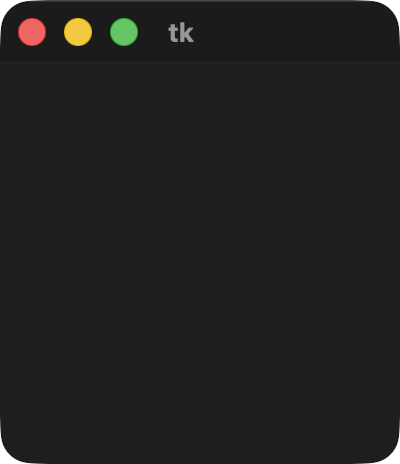

In [1]:
import tkinter
from browser import display_tk_window

# 책과 같이 window를 직접 만든다. mainloop() 대신 캡처 후 창을 닫는다.
# (커널에 GUI가 남으면 Restart Kernel)
window = tkinter.Tk()
# tkinter.mainloop()
display_tk_window(window)

### 2.2 창에 그리기

2026-07-20 20:02:15.875 Python[76162:20913622] error messaging the mach port for IMKCFRunLoopWakeUpReliable


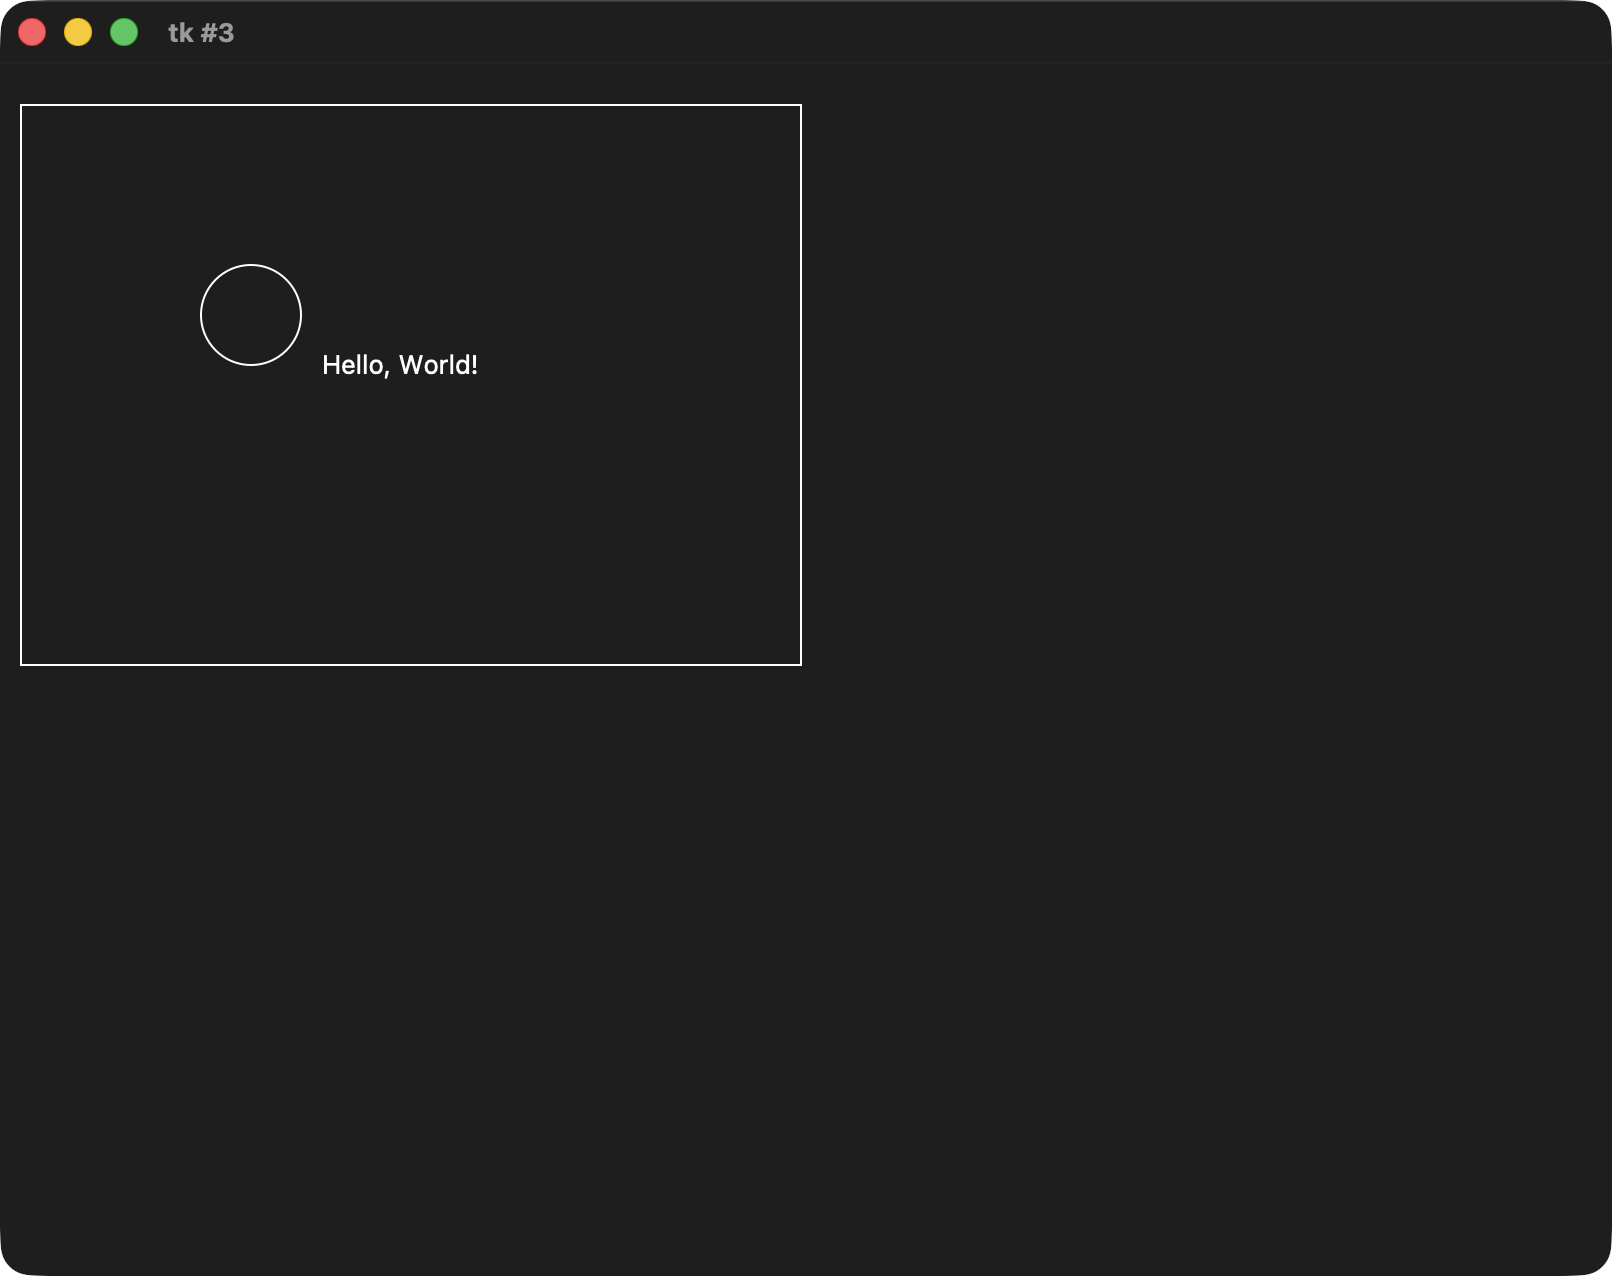

In [3]:
import tkinter
from browser import display_tk_window

WIDTH, HEIGHT = 800, 600

class Browser:
    def __init__(self):
        self.window = tkinter.Tk()
        self.canvas = tkinter.Canvas(self.window, width=WIDTH, height=HEIGHT)
        self.canvas.pack()

    def display(self):
        display_tk_window(self.window)

    def load(self, url):
        # ...
        self.canvas.create_rectangle(10, 20, 400, 300)
        self.canvas.create_oval(100, 100, 150, 150)
        self.canvas.create_text(200, 150, text="Hello, World!")

browser = Browser()
browser.load("https://www.google.com")
browser.display()

### 2.3 텍스트 배치하기

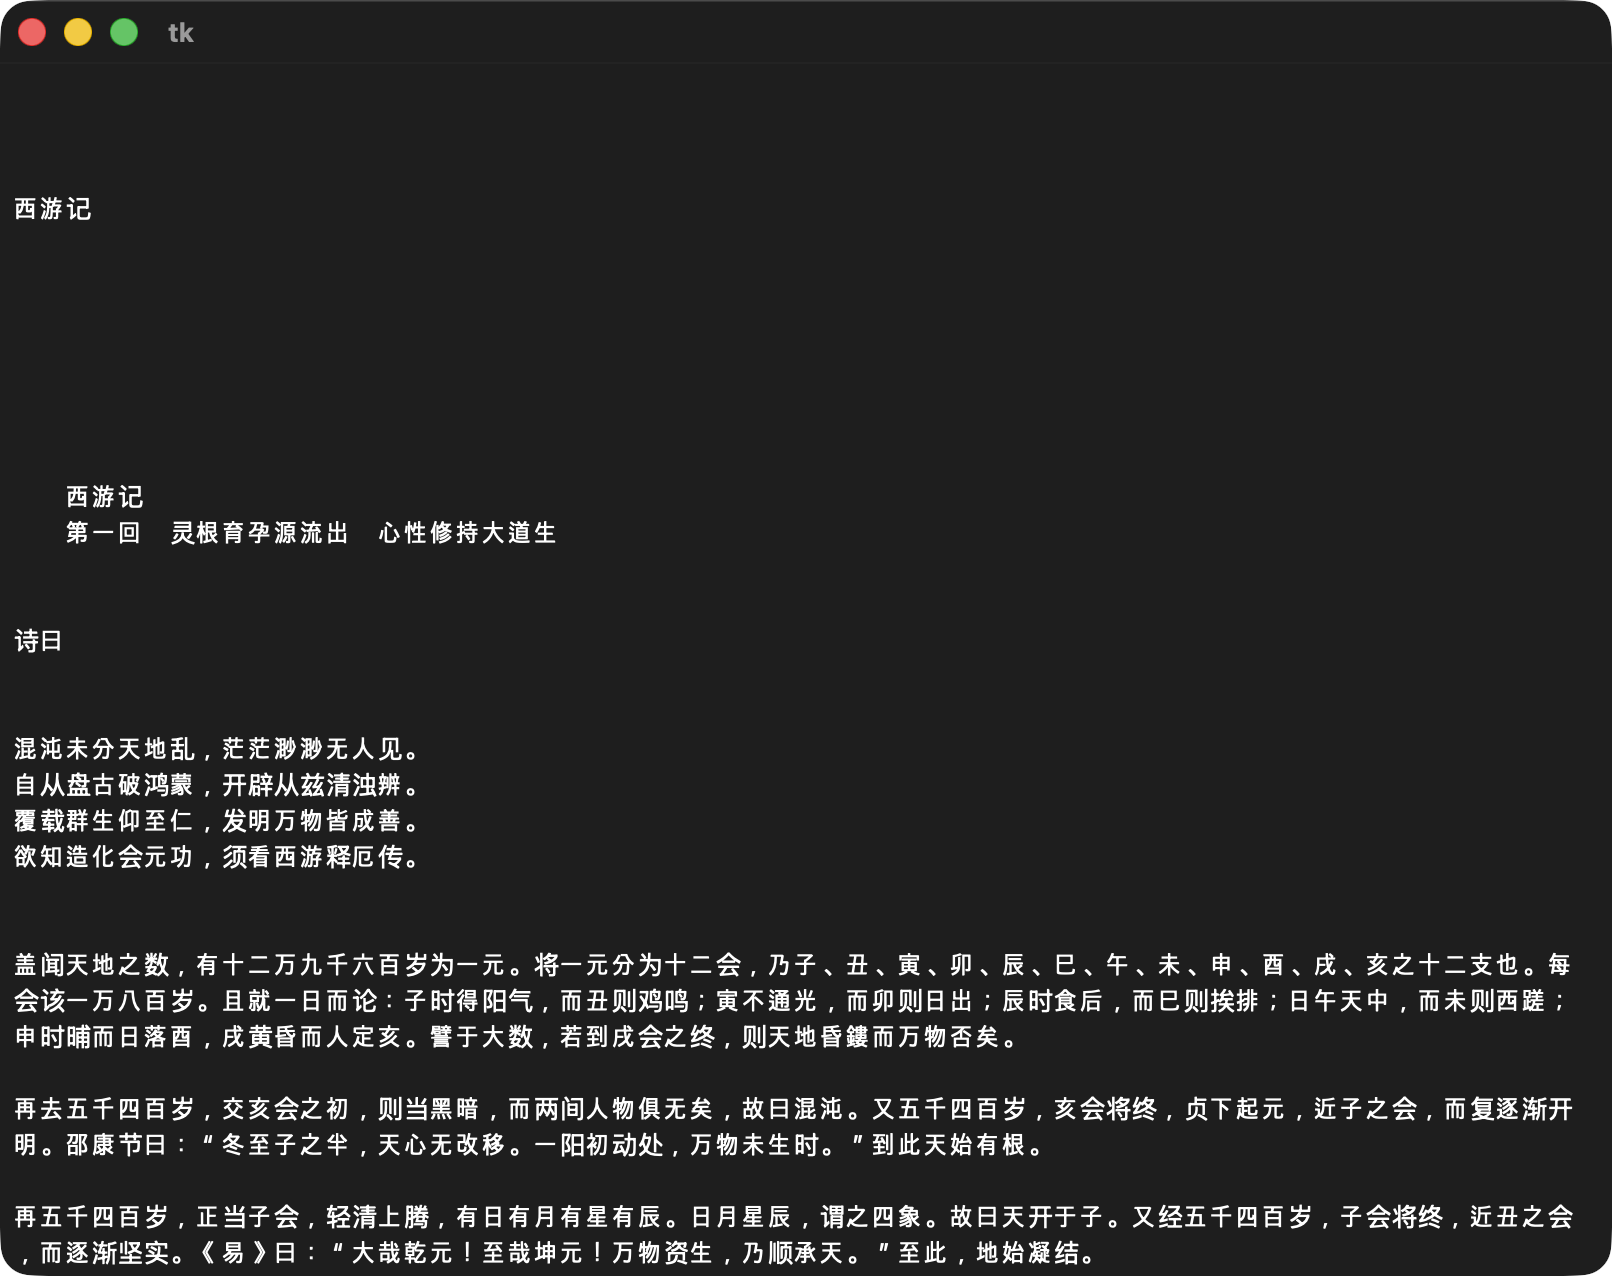

In [1]:
import tkinter
from browser.url import URL, lex
from browser.tk_capture import display_tk_window

WIDTH, HEIGHT = 800, 600

class Browser:
    def __init__(self):
        self.window = tkinter.Tk()
        self.canvas = tkinter.Canvas(self.window, width=WIDTH, height=HEIGHT)
        self.canvas.pack()

    def display(self):
        display_tk_window(self.window)

    def load(self, url, headers=None):
        body = url.request(headers=headers)
        text = lex(body, url.scheme)
        HSTEP, VSTEP = 13, 18
        cursor_x, cursor_y = HSTEP, VSTEP
        for c in text:
            self.canvas.create_text(cursor_x, cursor_y, text=c)
            cursor_x += HSTEP
            if c == "\n":
                cursor_x = HSTEP
                cursor_y += VSTEP
            if cursor_x >= WIDTH - HSTEP:
                cursor_x = HSTEP
                cursor_y += VSTEP

browser = Browser()
browser.load(URL("https://browser.engineering/examples/xiyouji.html"))
browser.display()

### 2.4 텍스트 스크롤하기

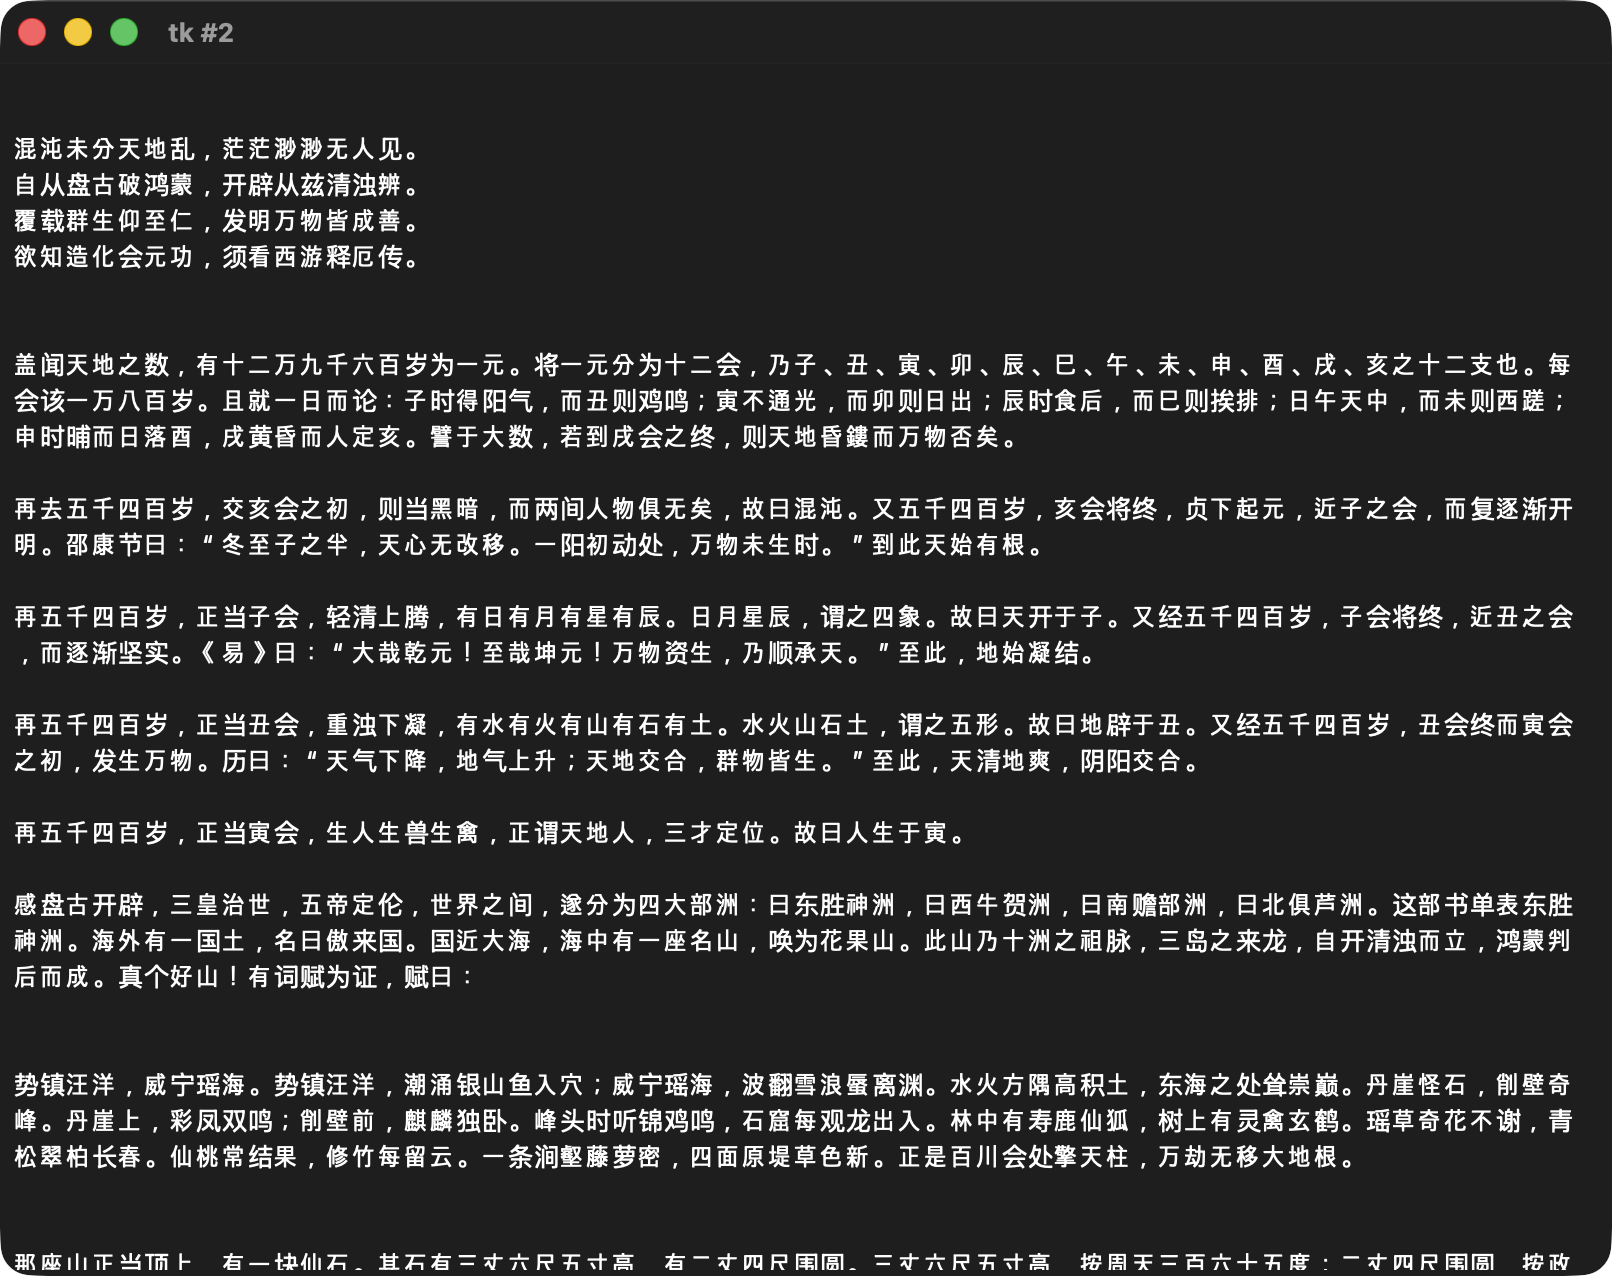

In [4]:
import tkinter
from browser.url import URL, lex
from browser.tk_capture import display_tk_window

WIDTH, HEIGHT = 800, 600
HSTEP, VSTEP = 13, 18
SCROLL_STEP = 100

def layout(text):
    display_list = []
    cursor_x, cursor_y = HSTEP, VSTEP
    for c in text:
        display_list.append((cursor_x, cursor_y, c))
        cursor_x += HSTEP
        if c == "\n":
            cursor_x = HSTEP
            cursor_y += VSTEP
        if cursor_x >= WIDTH - HSTEP:
            cursor_x = HSTEP
            cursor_y += VSTEP
    return display_list

class Browser:
    def __init__(self):
        self.window = tkinter.Tk()
        self.canvas = tkinter.Canvas(self.window, width=WIDTH, height=HEIGHT)
        self.canvas.pack()
        self.scroll = 0
        self.window.bind("<Down>", self.scrolldown)

    def display(self):
        display_tk_window(self.window)

    def draw(self):
        self.canvas.delete("all")
        for x, y, c in self.display_list:
            self.canvas.create_text(x, y - self.scroll, text=c)

    def scrolldown(self, e=None):
        self.scroll += SCROLL_STEP
        self.draw()

    def load(self, url, headers=None):
        body = url.request(headers=headers)
        text = lex(body, url.scheme)
        self.display_list = layout(text)
        self.draw()

browser = Browser()
browser.load(URL("https://browser.engineering/examples/xiyouji.html"))
browser.scrolldown()
browser.scrolldown()
browser.scrolldown()
browser.display()